In [1]:
# If imbalanced-learn is not installed, uncomment the next line and run it once.
# !pip install imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler

pd.set_option("display.max_columns", None)

In [31]:
df = pd.read_csv("/content/Fraud Detection Dataset (1).csv")
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [7]:
print(list(df.columns))

['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']


# Partition

In [8]:
split_fraction = 0.70
partition = df.sample(frac=split_fraction, random_state=42)
print("Partition size:", len(partition))
partition.head()

Partition size: 35700


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


# Random

In [9]:
sample_random = df.sample(n=100, random_state=42)
sample_random.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


# Stratified

In [12]:
sample_stratified = (
    df.groupby("Location", group_keys=False)
      .apply(lambda x: x.sample(frac=0.10, random_state=42))
      .reset_index(drop=True)
)
print("Stratified sample size:", len(sample_stratified))
sample_stratified.head()

Stratified sample size: 4844


/tmp/ipykernel_1215/3833663789.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=0.10, random_state=42))


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
1,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
2,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
3,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
4,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


## Task 1: Fix Number of Sample (500 only)

In [13]:
# Take exactly 500 observations from the complete dataset
sample_500 = df.sample(n=500, random_state=42)
print("Sample size:", len(sample_500))
sample_500.head()

Sample size: 500


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
4207,T4208,2440,1914.57,Online Purchase,21.0,Mobile,Seattle,1,40,12,Debit Card,0
6583,T6584,4693,2987.32,POS Payment,8.0,Desktop,Boston,2,85,13,Credit Card,0
13538,T13539,3457,1338.51,Bill Payment,14.0,Desktop,Boston,3,92,10,Credit Card,0
38447,T38448,1111,3142.30,ATM Withdrawal,NaN,Desktop,Seattle,4,47,9,Credit Card,0
22267,T22268,3178,NaN,POS Payment,16.0,Mobile,Los Angeles,3,61,14,Debit Card,0


## Task 2: Country-wise list/count

In [17]:
location_counts = df["Location"].value_counts().reset_index()
location_counts.columns = ["Location", "Count"]
location_counts

,Location,Count
0,Boston,6149
1,New York,6110
2,Seattle,6104
3,Chicago,6071
4,Houston,6031
5,Los Angeles,6012
6,Miami,5991
7,San Francisco,5985


## Task 3: Equalize the country wise count

In [18]:
# Use the smallest location count as the common sample size
min_location_count = df["Location"].value_counts().min()

sample_equal = (
    df.groupby("Location", group_keys=False)
      .apply(lambda x: x.sample(n=min_location_count, random_state=42), include_groups=False)
      .reset_index(drop=True)
)

print("Records per location after equalization:")
# Note: Since include_groups=False was used, Location won't be inside sample_equal,
# but we can re-verify the original group counts or adapt the code accordingly.
# Let's adjust to keep the Location column by selecting it after groupby or by restructuring:
sample_equal = (
    df.groupby("Location", group_keys=True)
      .apply(lambda x: x.sample(n=min_location_count, random_state=42))
      .reset_index(drop=True)
)

print("Records per location after equalization:")
print(sample_equal["Location"].value_counts())
sample_equal.head()

Records per location after equalization:
Records per location after equalization:
Location
Boston           5985
Chicago          5985
Houston          5985
Los Angeles      5985
Miami            5985
New York         5985
San Francisco    5985
Seattle          5985
Name: count, dtype: int64


/tmp/ipykernel_1215/1308457209.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min_location_count, random_state=42))


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T23598,2623,24.05,Bank Transfer,5.0,Tablet,Boston,2,48,14,Net Banking,0
1,T1508,3062,4546.33,Bill Payment,5.0,Tablet,Boston,4,28,11,Invalid Method,0
2,T43720,4328,NaN,Online Purchase,NaN,NaN,Boston,1,7,11,NaN,0
3,T40026,1565,4865.36,Bank Transfer,22.0,Mobile,Boston,0,95,6,Debit Card,0
4,T41639,3276,3711.51,Bank Transfer,NaN,Tablet,Boston,0,56,8,Credit Card,0


# Cluster

In [20]:
locations = df["Location"].dropna().unique()
selected_locations = pd.Series(locations).sample(n=min(2, len(locations)), random_state=42)
sample_cluster = df[df["Location"].isin(selected_locations)]
print("Selected locations:", selected_locations.tolist())
sample_cluster.head(36)

Selected locations: ['New York', 'Miami']


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
16,T17,4171,3960.52,Bank Transfer,13.0,Tablet,Miami,2,68,8,Debit Card,0
17,T18,3919,2327.71,Online Purchase,20.0,NaN,Miami,4,21,1,Debit Card,0
20,T21,2685,973.51,Bill Payment,2.0,Mobile,New York,1,43,12,UPI,0
21,T22,4380,2553.98,ATM Withdrawal,3.0,Mobile,Miami,1,7,9,Net Banking,0
22,T23,1769,2222.86,POS Payment,14.0,Mobile,Miami,1,103,10,UPI,0
25,T26,4485,NaN,Online Purchase,17.0,Mobile,Miami,2,63,8,UPI,0
26,T27,3853,4065.44,Online Purchase,21.0,Tablet,New York,4,99,9,Net Banking,0
30,T31,3324,428.39,POS Payment,20.0,Desktop,New York,0,85,10,Credit Card,0
32,T33,1459,2212.25,Online Purchase,10.0,Desktop,New York,4,14,13,UPI,0


## Task 4: Sample from 5 most/least listed countries

In [22]:
location_counts = df["Location"].value_counts()
most_listed = location_counts.head(5).index.tolist()
least_listed = location_counts.tail(5).index.tolist()
selected = most_listed + least_listed

# Take up to 10 records from each selected location
sample_most_least = (
    df[df["Location"].isin(selected)]
      .groupby("Location", group_keys=False)
      .apply(lambda x: x.sample(n=min(10, len(x)), random_state=42), include_groups=False)
      .reset_index(drop=True)
)

print("5 most listed locations:", most_listed)
print("5 least listed locations:", least_listed)
# Since we set include_groups=False, we can confirm the resulting shape instead or keep group keys if location is required in the output

5 most listed locations: ['Boston', 'New York', 'Seattle', 'Chicago', 'Houston']
5 least listed locations: ['Chicago', 'Houston', 'Los Angeles', 'Miami', 'San Francisco']


# Data Selection

1. Missing Value
2. Identical Values
3. Correlation Analysis
4. Chi-Square Test

Missing values:
Time_of_Transaction    2552
Location               2547
Transaction_Amount     2520
Device_Used            2473
Payment_Method         2469
dtype: int64

Duplicate rows: 881


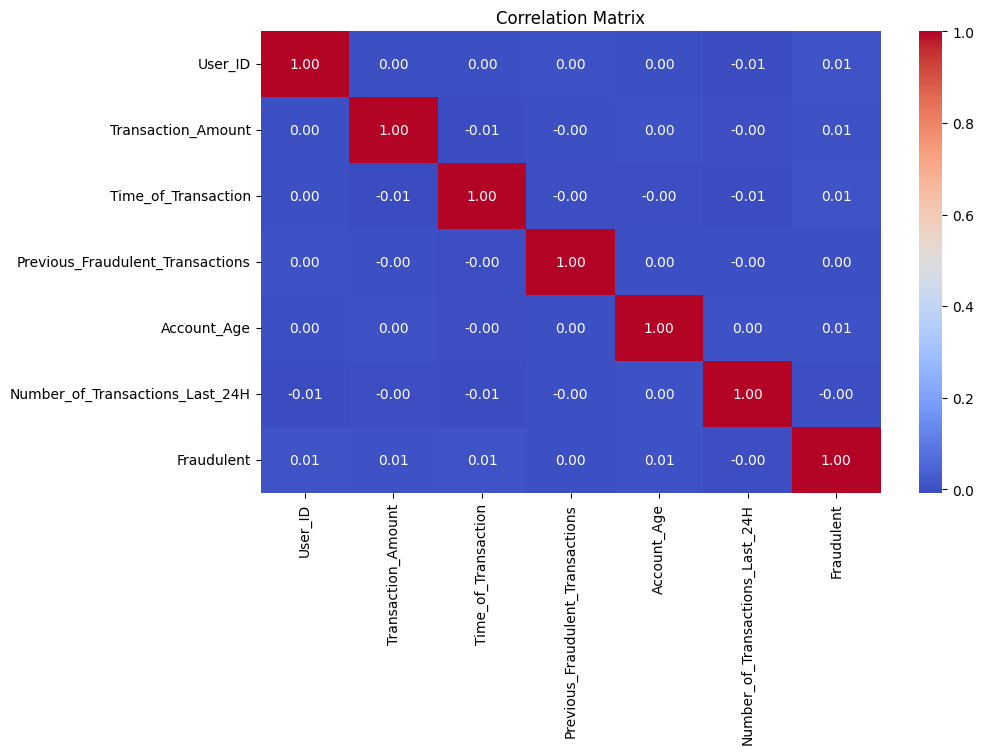

In [23]:
# 1. Missing value analysis
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print("Missing values:")
print(missing if len(missing) else "No missing values found")

# 2. Identical/duplicate records
print("\nDuplicate rows:", df.duplicated().sum())

# 3. Correlation analysis for numeric variables
numeric_df = df.select_dtypes(include=np.number)
if numeric_df.shape[1] >= 2:
    corr = numeric_df.corr()
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()
else:
    print("Not enough numeric columns for correlation analysis.")

In [25]:
# 4. Chi-Square test for categorical variables against Fraud
from scipy.stats import chi2_contingency

if "Fraud" in df.columns:
    categorical_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    categorical_cols = [c for c in categorical_cols if c != "Fraud"]
    chi_results = []

    for col in categorical_cols:
        table = pd.crosstab(df[col], df["Fraud"])
        if table.shape[0] > 1 and table.shape[1] > 1:
            chi_stat, p_value, _, _ = chi2_contingency(table)
            chi_results.append([col, chi_stat, p_value])

    chi_results = pd.DataFrame(chi_results, columns=["Feature", "Chi-Square", "p-value"])
    chi_results = chi_results.sort_values("p-value")
    chi_results.head(10)
else:
    print("Fraud column is not available in the dataset.")

Fraud column is not available in the dataset.


In [27]:
# Prepare X and Y for the ML model
X = df.drop(columns=["Fraudulent"])
Y = df["Fraudulent"].copy()

if Y.dtype == "object" or str(Y.dtype) == "category":
    target_encoder = LabelEncoder()
    Y = target_encoder.fit_transform(Y.astype(str))
else:
    Y = Y.astype(int)

print("Target distribution:")
print(pd.Series(Y).value_counts())

Target distribution:
Fraudulent
0    48490
1     2510
Name: count, dtype: int64


# Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, stratify=Y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 40800
Testing rows: 10200


## Task 5: ML Model

In [29]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Balance only the training data
ros = RandomOverSampler(random_state=42)
X_train_balanced, y_train_balanced = ros.fit_resample(X_train_processed, y_train)

print("Before oversampling:", pd.Series(y_train).value_counts().to_dict())
print("After oversampling:", pd.Series(y_train_balanced).value_counts().to_dict())

model = LogisticRegression(max_iter=1000)
model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1] if len(np.unique(y_train_balanced)) == 2 else None

Before oversampling: {0: 38792, 1: 2008}
After oversampling: {0: 38792, 1: 38792}


## Result Analysis

Accuracy: 0.9521

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.98      9698
           1       1.00      0.03      0.05       502

    accuracy                           0.95     10200
   macro avg       0.98      0.51      0.51     10200
weighted avg       0.95      0.95      0.93     10200

ROC-AUC: 0.5103


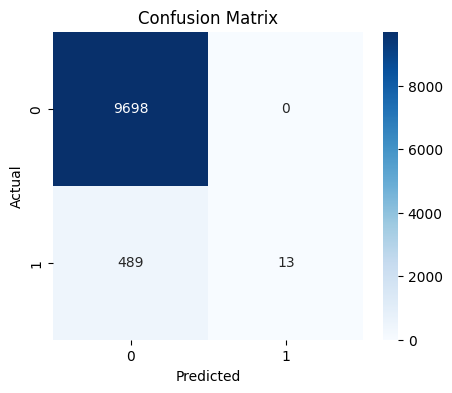

In [30]:
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

if y_prob is not None and len(np.unique(y_test)) == 2:
    print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

### Observation
The model should be judged using more than accuracy because fraud data can be imbalanced. Precision, recall, F1-score and ROC-AUC give a better view of how well fraudulent cases are being identified. Random oversampling is applied only to the training data, keeping the test set untouched for a fair evaluation.